In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

df = pd.read_csv("../Data/processed/customer_churn_features.csv")

X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

logistic_model = joblib.load("../Models/logistic_model.pkl")
rf_model = joblib.load("../Models/random_forest_model.pkl")
xgb_model = joblib.load("../Models/xgboost_model.pkl")

In [2]:
#Predictions 
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.783333,0.686957,0.456647,0.548611,0.796700
1,Random Forest,0.765000,0.602564,0.543353,0.571429,0.768163
2,XGBoost,0.781667,0.672131,0.473988,0.555932,0.768069


In [3]:
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(), "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


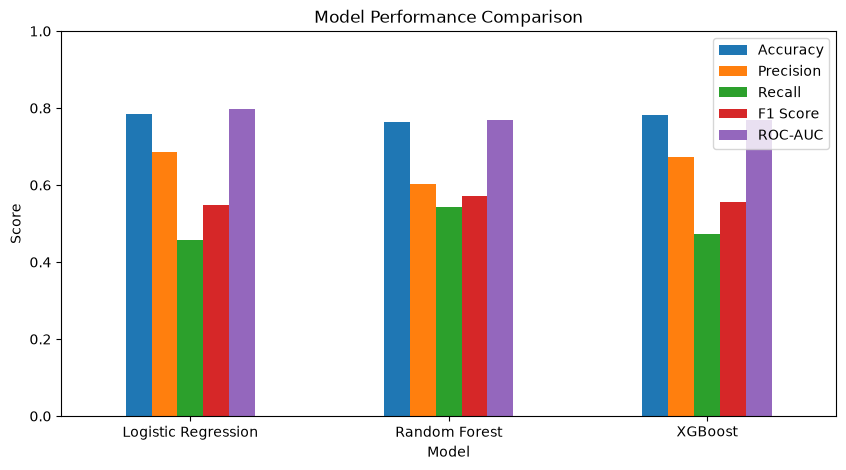

In [4]:
#Comparison graph
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar", figsize=(10,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

In [5]:
best_model = models[best_model_name]

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       427
           1       0.69      0.46      0.55       173

    accuracy                           0.78       600
   macro avg       0.75      0.69      0.70       600
weighted avg       0.77      0.78      0.77       600



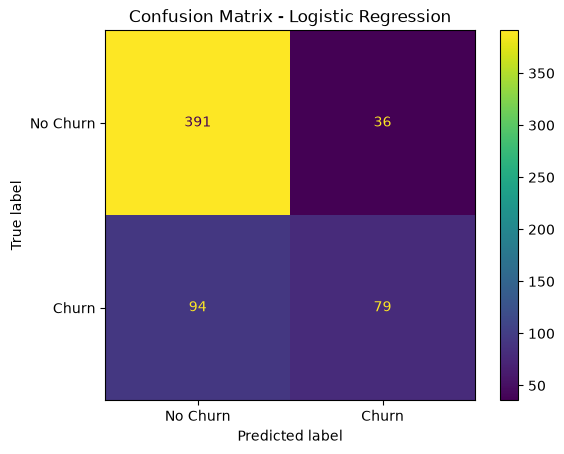

In [6]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [7]:
results_df.to_csv(
    "../Reports/model_comparison.csv",
    index=False
)

print("Model evaluation completed!")

Model evaluation completed!
